# Exploratory Data Analysis (EDA)


### Objective
Explore the cleaned dataset to understand feature distributions, relationships, and patterns that may influence machine diagnostics before feature engineering and model development.

In [1]:
## 1. Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
## 2. Load the Cleaned Dataset
df = pd.read_csv("../data/processed/cleaned_data.csv",
                 parse_dates=["Date"])

In [3]:
# Display the first five rows
df.head()

,Date,System,Control,Type,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Diagnostic
0,2014-04-15 11:56:00,0,C,M,300.064358,310.033081,1541.242402,42.8,0.00000,No failure
1,2014-04-12 16:09:00,0,A,L,298.200000,308.700000,1408.000000,39.9,110.52424,No failure
2,2014-04-13 01:13:00,0,A,L,298.100000,308.500000,1498.000000,39.9,110.52424,No failure
3,2014-07-24 20:35:00,0,B,L,300.064358,310.033081,1433.000000,39.5,110.52424,No failure
4,2014-07-22 01:31:00,0,C,L,300.064358,310.033081,1541.242402,40.0,9.00000,No failure


In [4]:
# Check the dimensions of the dataset (rows and columns)
df.shape

(10000, 10)

In [5]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     10000 non-null  datetime64[us]
 1   System                   10000 non-null  int64         
 2   Control                  10000 non-null  str           
 3   Type                     10000 non-null  str           
 4   Air temperature (K)      10000 non-null  float64       
 5   Process temperature (K)  10000 non-null  float64       
 6   Rotational speed (rpm)   10000 non-null  float64       
 7   Torque (Nm)              10000 non-null  float64       
 8   Tool wear (min)          10000 non-null  float64       
 9   Diagnostic               10000 non-null  str           
dtypes: datetime64[us](1), float64(5), int64(1), str(3)
memory usage: 781.4 KB


In [6]:
# Count the occurrences of each diagnostic class
df["Diagnostic"].value_counts()

Diagnostic
No failure                  9652
Heat Dissipation Failure     106
Overstrain Failure            98
Power Failure                 83
Tool Wear Failure             42
Random Failures               19
Name: count, dtype: int64

### Observation

- The dataset is highly imbalanced.
- "No failure" is the dominant class with 9,652 records (96.52%).
- All failure classes are relatively rare, with "Random Failures" being the least frequent (19 records).
- This imbalance suggests that accuracy alone may not be a reliable evaluation metric, and additional metrics such as Precision, Recall, and F1-score should be considered during model evaluation.

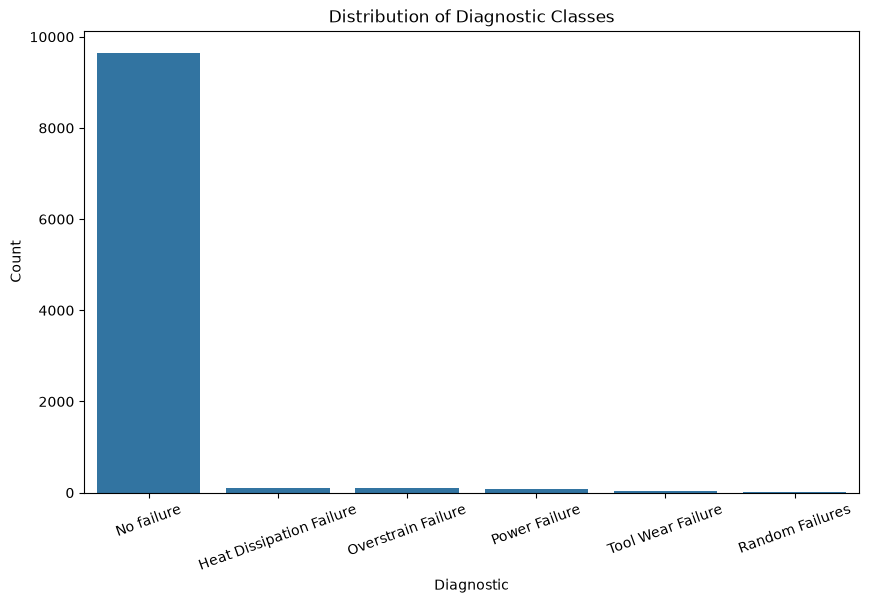

In [7]:
# Visualize the distribution of the target variable
plt.figure(figsize=(10, 6))

sns.countplot(data=df, x="Diagnostic",order=df["Diagnostic"].value_counts().index)

plt.title("Distribution of Diagnostic Classes")
plt.xlabel("Diagnostic")
plt.ylabel("Count")

plt.xticks(rotation=20)

plt.show()


### Observation

- The "No failure" class is the dominant category in the dataset.
- Failure classes occur much less frequently, indicating a highly imbalanced dataset.
- Random Failures is the least frequent class.
- Class imbalance should be considered during model evaluation since accuracy alone may not reflect model performance.

In [8]:
# Calculate the percentage distribution of each diagnostic class
diagnostic_percentage = df["Diagnostic"].value_counts(normalize=True) * 100

diagnostic_percentage.round(2)

Diagnostic
No failure                  96.52
Heat Dissipation Failure     1.06
Overstrain Failure           0.98
Power Failure                0.83
Tool Wear Failure            0.42
Random Failures              0.19
Name: proportion, dtype: float64

### Observation

- The "No failure" class accounts for approximately 96.52% of the dataset.
- All failure classes together represent only about 3.48% of the observations.
- This confirms that the dataset is highly imbalanced.
- The imbalance should be considered during model training and evaluation.

## Numerical Feature Analysis


In [9]:
# Display summary statistics for Air Temperature
df["Air temperature (K)"].describe()

count    10000.000000
mean       300.064358
std          1.182135
min        295.400000
25%        300.064358
50%        300.064358
75%        300.064358
max        304.300000
Name: Air temperature (K), dtype: float64

In [10]:
# Display the unique values in Air Temperature
df["Air temperature (K)"].unique()

array([300.06435845, 298.2       , 298.1       , 298.6       ,
       298.7       , 298.8       , 298.9       , 299.        ,
       298.4       , 298.3       , 298.        , 297.9       ,
       297.8       , 297.7       , 297.6       , 297.5       ,
       297.4       , 297.3       , 297.2       , 296.9       ,
       296.6       , 296.7       , 296.8       , 296.5       ,
       296.3       , 296.1       , 295.9       , 295.8       ,
       295.7       , 295.6       , 295.4       , 295.5       ,
       296.        , 296.2       , 296.4       , 297.        ,
       297.1       , 298.5       , 299.1       , 299.3       ,
       299.5       , 299.7       , 299.4       , 299.2       ,
       299.6       , 299.8       , 299.9       , 300.        ,
       300.1       , 300.2       , 300.3       , 300.4       ,
       300.5       , 300.6       , 300.7       , 300.8       ,
       300.9       , 301.        , 301.2       , 301.1       ,
       301.3       , 301.4       , 301.5       , 301.6 

In [11]:
# Count the number of unique values
df["Air temperature (K)"].nunique()

91

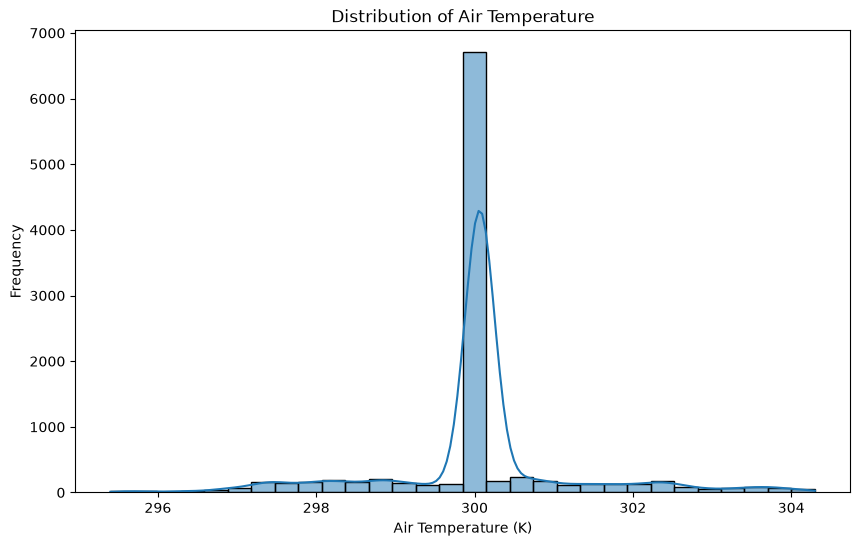

In [12]:
# Visualize the distribution of Air Temperature

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Air temperature (K)",
    bins=30,
    kde=True
)

plt.title("Distribution of Air Temperature")
plt.xlabel("Air Temperature (K)")
plt.ylabel("Frequency")

plt.show()

### Observation

- The Air Temperature feature shows a strong concentration around 300 K.
- A very prominent peak is observed near the mean value.
- This spike is likely due to mean imputation performed during the data cleaning stage.
- The feature exhibits reduced variability around the imputed value, which should be considered during further analysis and model development.

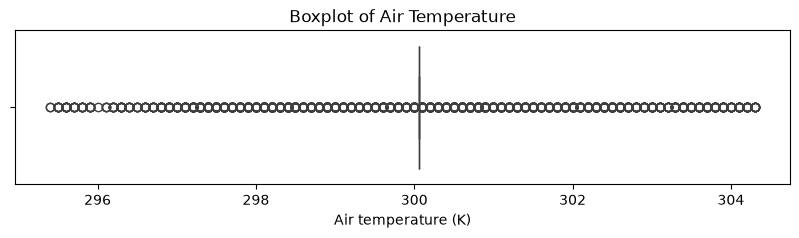

In [13]:
# Visualize the spread and potential outliers of Air Temperature
plt.figure(figsize=(10,2))

sns.boxplot(data=df,x='Air temperature (K)')

plt.title("Boxplot of Air Temperature")

plt.show()

### Observation

- The box plot has collapsed into a line because Q1, Median, and Q3 are identical.
- This resulted in an interquartile range (IQR) of zero.
- Many observations are displayed as potential outliers due to the collapsed IQR.
- These points are primarily a consequence of mean imputation rather than true anomalous sensor readings.

In [14]:
# Display summary statistics for Process Temperature
df["Process temperature (K)"].describe()

count    10000.000000
mean       310.033081
std          0.866110
min        305.800000
25%        310.033081
50%        310.033081
75%        310.033081
max        313.800000
Name: Process temperature (K), dtype: float64

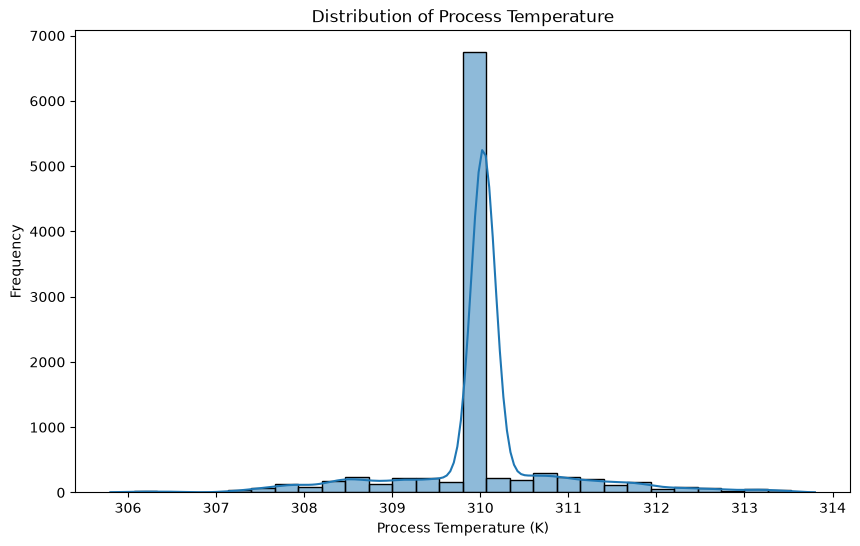

In [15]:
# Visualize the distribution of Process Temperature

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Process temperature (K)",
    bins=30,
    kde=True
)

plt.title("Distribution of Process Temperature")
plt.xlabel("Process Temperature (K)")
plt.ylabel("Frequency")

plt.show()

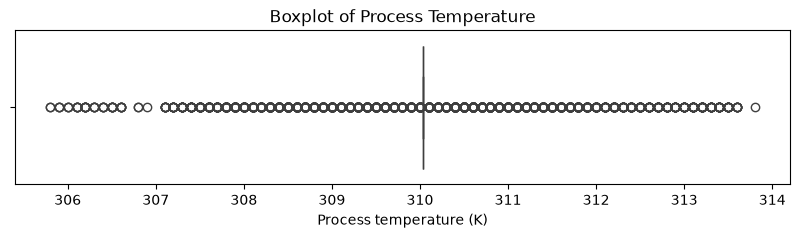

In [16]:
# Visualize the spread and potential outliers of Air Temperature
plt.figure(figsize=(10,2))

sns.boxplot(data=df,x='Process temperature (K)')

plt.title("Boxplot of Process Temperature")

plt.show()

### Observation

- Process Temperature shows a distribution similar to Air Temperature.
- A strong peak is observed around the mean due to mean imputation.
- The box plot collapses because the interquartile range (IQR) is zero.
- The apparent outliers are largely a consequence of preprocessing rather than abnormal sensor behavior.

In [17]:
# Display summary statistics for Rotational Speed
df["Rotational speed (rpm)"].describe()

count    10000.000000
mean      1541.242402
std        152.421284
min       1168.000000
25%       1462.000000
50%       1541.242402
75%       1551.000000
max       2886.000000
Name: Rotational speed (rpm), dtype: float64

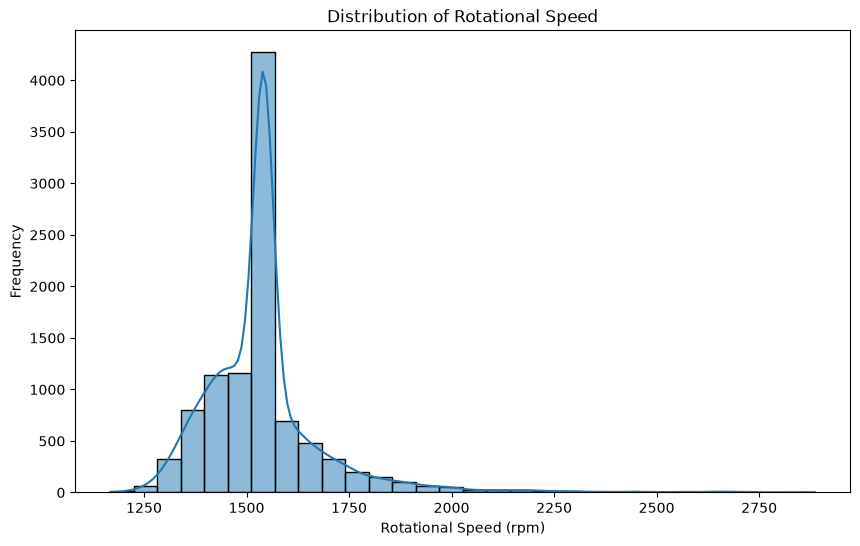

In [18]:
# Visualize the distribution of Rotational Speed (rpm)

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Rotational speed (rpm)",
    bins=30,
    kde=True
)

plt.title("Distribution of Rotational Speed")
plt.xlabel("Rotational Speed (rpm)")
plt.ylabel("Frequency")

plt.show()

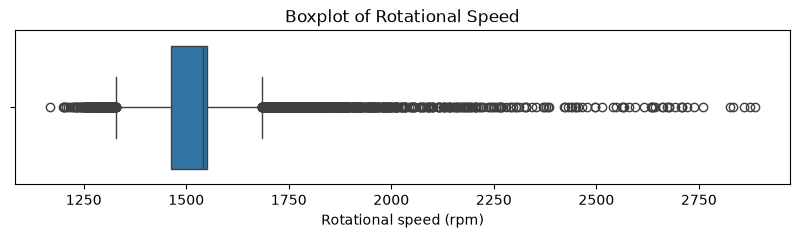

In [19]:
# Visualize the spread and potential outliers of Rotational Speed
plt.figure(figsize=(10,2))

sns.boxplot(data=df,x='Rotational speed (rpm)')

plt.title("Boxplot of Rotational Speed")

plt.show()

### Observation

- Rotational Speed shows greater variability than the temperature features.
- A noticeable peak around the mean suggests the effect of mean imputation, but the overall distribution is still preserved.
- The distribution is positively skewed, with a longer tail toward higher rotational speeds.
- The box plot reveals several potential outliers, which should be investigated further before deciding whether they require treatment.

In [20]:
# Display summary statistics for Torque
df["Torque (Nm)"].describe()

count    10000.000000
mean        39.943080
std          8.234322
min          3.800000
25%         36.900000
50%         39.900000
75%         43.000000
max         76.600000
Name: Torque (Nm), dtype: float64

### Observation

- Torque has a well-defined interquartile range, indicating that the distribution has retained its variability.
- The mean and median are very close, suggesting a nearly symmetric distribution.
- The wide range of values indicates the presence of potential outliers that should be verified using visualizations.

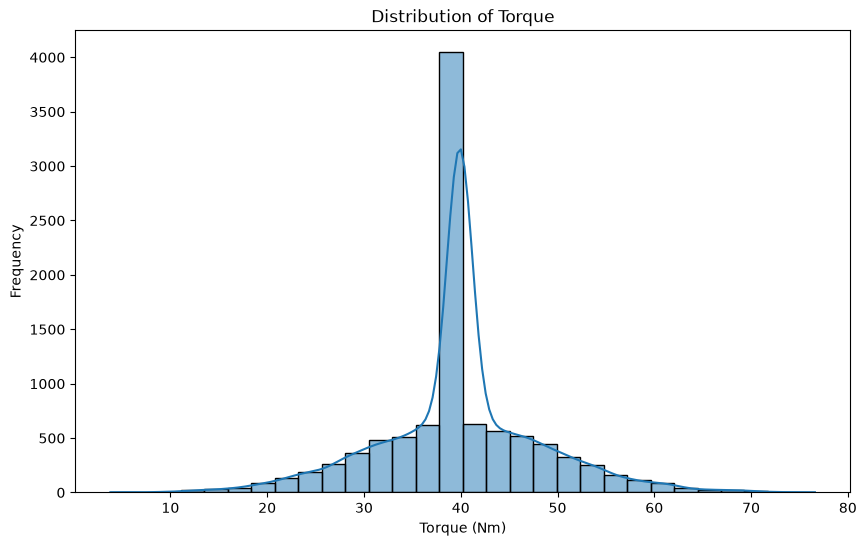

In [21]:
# Visualize the distribution of Torque

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Torque (Nm)",
    bins=30,
    kde=True
)

plt.title("Distribution of Torque")
plt.xlabel("Torque (Nm)")
plt.ylabel("Frequency")

plt.show()

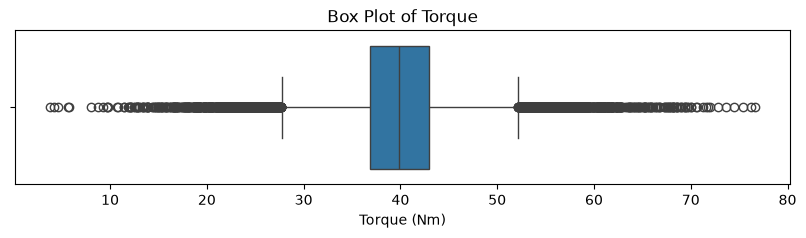

In [22]:
# Visualize the spread and potential outliers of Torque

plt.figure(figsize=(10,2))

sns.boxplot(
    data=df,
    x="Torque (Nm)"
)

plt.title("Box Plot of Torque")

plt.show()

### Observation

- Torque exhibits a nearly symmetric distribution with a slight right skew.
- A noticeable peak around the mean suggests the effect of mean imputation.
- The overall distribution remains well preserved despite preprocessing.
- The box plot identifies potential outliers on both the lower and upper ends, which should be investigated further before any treatment.

In [23]:
# Display summary statistics for Tool Wear
df["Tool wear (min)"].describe()

count    10000.000000
mean       110.524240
std         37.203202
min          0.000000
25%        110.524240
50%        110.524240
75%        110.524240
max        253.000000
Name: Tool wear (min), dtype: float64

### Observation

- Tool Wear exhibits the same behavior as the temperature features.
- The identical quartiles result in an interquartile range (IQR) of zero.
- This pattern is primarily due to the high percentage of missing values that were replaced using mean imputation.
- The distribution and box plot should therefore be interpreted in the context of the preprocessing step.

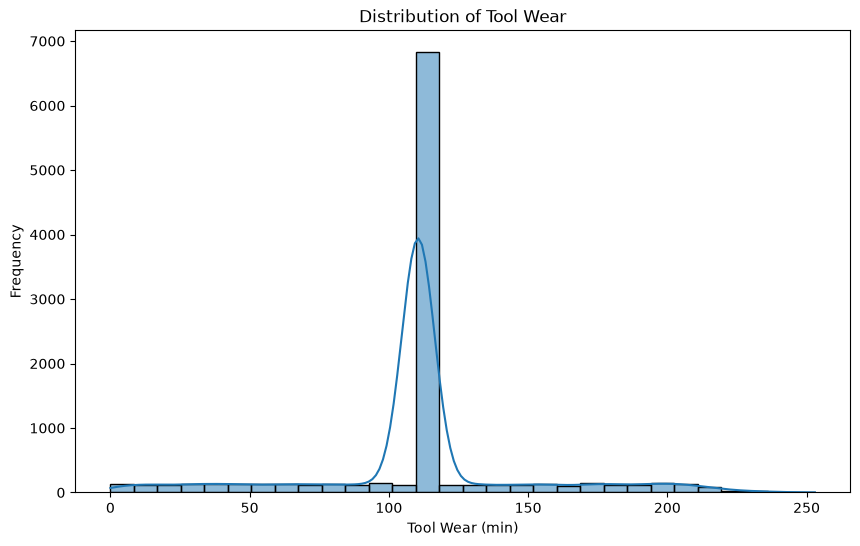

In [24]:
# Visualize the distribution of Tool Wear

plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="Tool wear (min)",
    bins=30,
    kde=True
)

plt.title("Distribution of Tool Wear")
plt.xlabel("Tool Wear (min)")
plt.ylabel("Frequency")

plt.show()

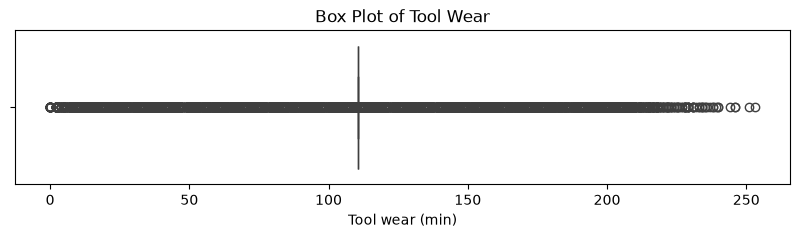

In [25]:
# Visualize the spread and potential outliers of Tool Wear

plt.figure(figsize=(10,2))

sns.boxplot(
    data=df,
    x="Tool wear (min)"
)

plt.title("Box Plot of Tool Wear")

plt.show()

### Observation

- Tool Wear exhibits a strong concentration around the mean due to mean imputation.
- The histogram confirms a dominant peak at the imputed value.
- The box plot collapses because the interquartile range (IQR) is zero.
- Numerous statistical outliers are observed, but these primarily result from preprocessing rather than true abnormal machine behavior.

In [26]:
# Create a list of numerical features for correlation analysis.
numerical_cols = [
    "Air temperature (K)",
    "Process temperature (K)",
    "Rotational speed (rpm)",
    "Torque (Nm)",
    "Tool wear (min)"
]

In [27]:
# Calculate the Pearson correlation matrix for the numerical features.
corr_matrix = df[numerical_cols].corr(method="pearson")
corr_matrix

,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min)
Air temperature (K),1.000000e+00,8.708646e-01,-1.495098e-04,7.313608e-16,-1.099871e-15
Process temperature (K),8.708646e-01,1.000000e+00,9.608193e-03,-1.768749e-14,5.772346e-15
Rotational speed (rpm),-1.495098e-04,9.608193e-03,1.000000e+00,-4.677747e-01,1.019278e-16
Torque (Nm),7.313608e-16,-1.768749e-14,-4.677747e-01,1.000000e+00,4.448064e-02
Tool wear (min),-1.099871e-15,5.772346e-15,1.019278e-16,4.448064e-02,1.000000e+00


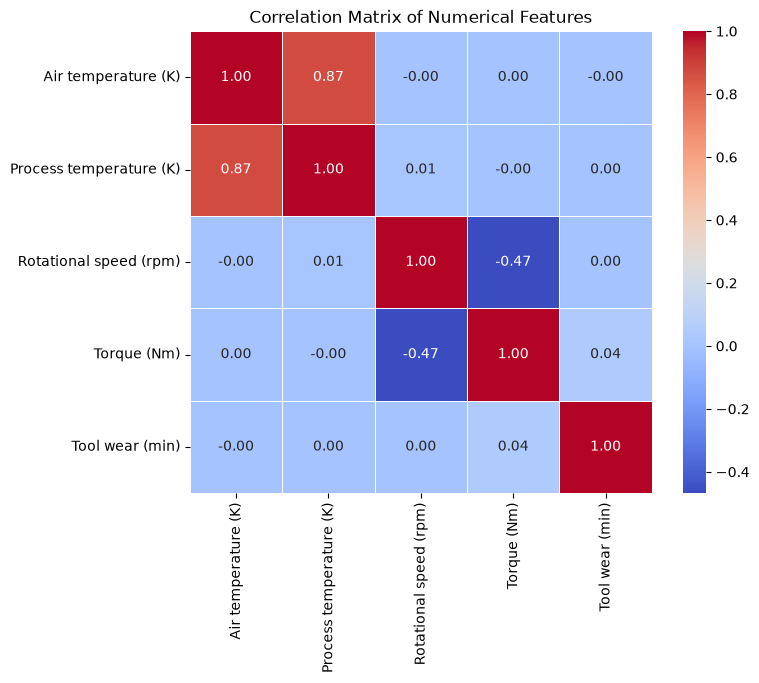

In [29]:
# Visualize the Pearson correlation matrix using a heatmap.
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar=True
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

### **Observations**

- Air Temperature and Process Temperature have a **strong positive correlation (0.87)**, indicating that both variables tend to increase together. This relationship is expected because the surrounding air temperature influences the machine's process temperature.

- Rotational Speed and Torque show a **moderate negative correlation (-0.47)**, suggesting that as rotational speed increases, torque tends to decrease. However, the relationship is not strong enough to indicate complete dependence.

- Most of the remaining feature pairs have correlation values close to **0**, indicating **little to no linear relationship** between them.

- No feature pair has a correlation greater than **±0.90**, indicating that there is **no severe multicollinearity** among the numerical features.

- Overall, the numerical features provide **mostly independent information**, which is beneficial for building machine learning models since they are not highly redundant.

## Categorical Feature Analysis

In [30]:
# Display the frequency distribution of the Type feature.
df["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

In [31]:
df["Type"].value_counts(normalize=True) * 100

Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64

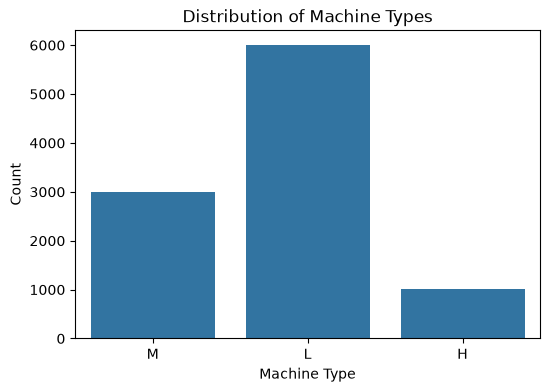

In [33]:
# Visualize the distribution of machine types.
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Type"
)

plt.title("Distribution of Machine Types")
plt.xlabel("Machine Type")
plt.ylabel("Count")

plt.show()



### **Observations**

- The dataset contains **three machine types**: **L, M, and H**.

- **Type L** is the most common machine type with **6,000 records (60.00%)**, making it the dominant category in the dataset.

- **Type M** contains **2,997 records (29.97%)**, representing nearly one-third of the dataset.

- **Type H** is the least common machine type with **1,003 records (10.03%)**.

- The machine type distribution is **imbalanced**, with the majority of observations belonging to **Type L**. This should be considered when analyzing failure patterns across different machine types.

In [34]:
# Display the frequency distribution of the Control feature.
df["Control"].value_counts()

Control
A    3437
C    3321
B    3242
Name: count, dtype: int64

In [35]:
df["Control"].value_counts(normalize=True) * 100

Control
A    34.37
C    33.21
B    32.42
Name: proportion, dtype: float64

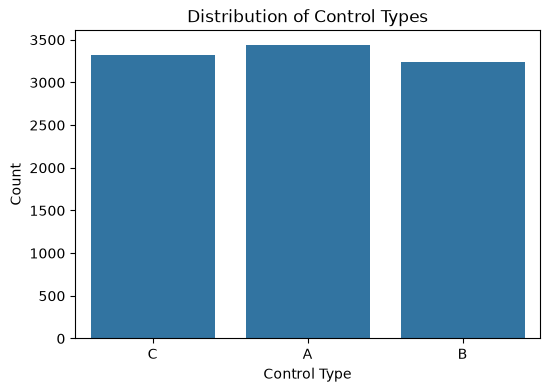

In [37]:
# Visualize the distribution of control types.
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Control"
)

plt.title("Distribution of Control Types")
plt.xlabel("Control Type")
plt.ylabel("Count")

plt.show()



### **Observations**

- The dataset contains **three control types**: **A, B, and C**.

- The distribution of control types is **nearly balanced**, with each category contributing approximately one-third of the dataset.

- **Control A** has the highest number of records (**34.37%**), followed by **Control C (33.21%)** and **Control B (32.42%)**.

- The small differences in the proportions indicate that the dataset does not have a significant imbalance among the control categories.

- Since the control types are well distributed, they are suitable for further analysis to investigate their relationship with machine failures.

## Relationship Analysis

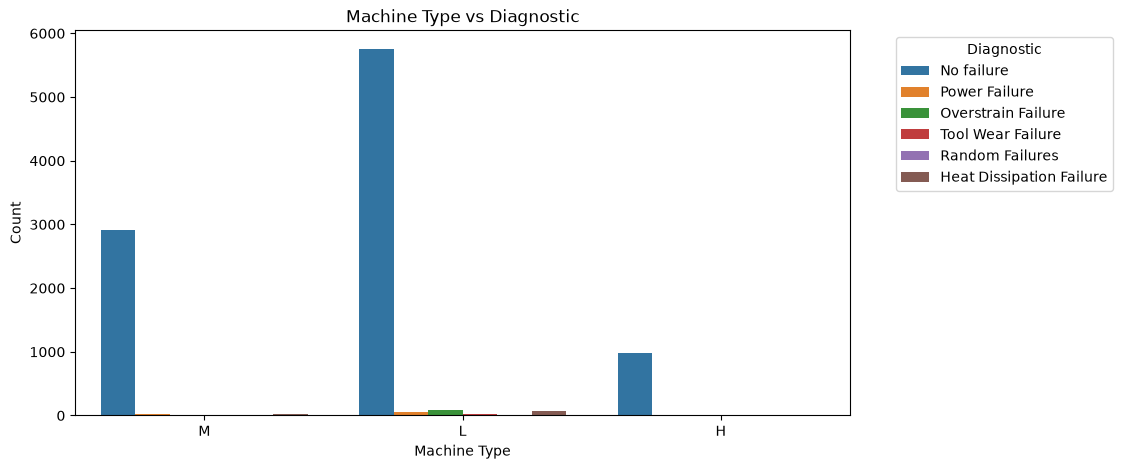

In [38]:
# Analyze the relationship between machine type and diagnostic outcome.
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Type",
    hue="Diagnostic"
)

plt.title("Machine Type vs Diagnostic")
plt.xlabel("Machine Type")
plt.ylabel("Count")

plt.legend(title="Diagnostic", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

In [39]:
pd.crosstab(df["Type"], df["Diagnostic"])

Diagnostic,Heat Dissipation Failure,No failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
Type,,,,,,
H,8,979,2,4,4,6
L,68,5757,87,51,13,24
M,30,2916,9,28,2,12


### **Observations**

- All three machine types are dominated by the **"No Failure"** category, indicating that most machines operate without failures regardless of their type.

- **Type L** records the highest number of failures across most failure categories. However, this is expected because **Type L also has the largest number of machines (6,000 records)** in the dataset.

- **Type H** has the lowest number of failures, but it also contains the fewest observations (**1,003 records**). Therefore, the lower failure count should not be interpreted as better reliability based on counts alone.

- The relationship between machine type and diagnostic outcome is influenced by the **unequal distribution of machine types**. A percentage-based comparison would provide a more accurate assessment of failure rates across machine types.

- Based on the count analysis alone, there is **no clear evidence** that a particular machine type is inherently more prone to failures.

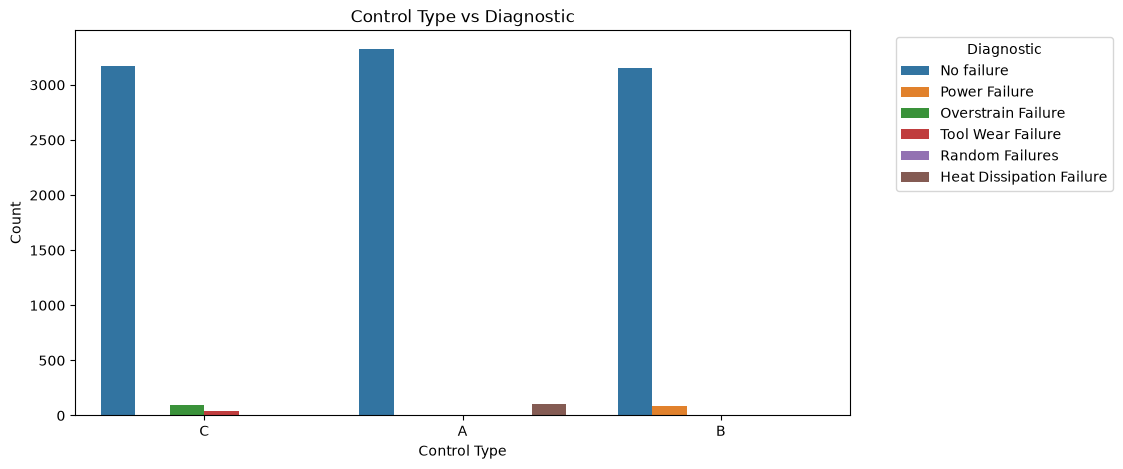

In [41]:
# Analyze the relationship between control type and diagnostic outcome.
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Control",
    hue="Diagnostic"
)

plt.title("Control Type vs Diagnostic")
plt.xlabel("Control Type")
plt.ylabel("Count")

plt.legend(title="Diagnostic", bbox_to_anchor=(1.05,1), loc="upper left")

plt.show()

In [42]:
pd.crosstab(df["Control"], df["Diagnostic"])

Diagnostic,Heat Dissipation Failure,No failure,Overstrain Failure,Power Failure,Random Failures,Tool Wear Failure
Control,,,,,,
A,106,3327,0,0,4,0
B,0,3151,0,83,8,0
C,0,3174,98,0,7,42


### **Observations**

- The majority of machines across all control types are classified as **"No Failure"**, indicating that normal operating conditions dominate the dataset.

- Different failure categories appear under different control types in this dataset. For example, Heat Dissipation Failure appears under **Control A**, Power Failure under **Control B**, and Overstrain Failure and Tool Wear Failure under **Control C**.

- The control categories are relatively balanced in size, making comparisons between them more reliable than comparisons across machine types.

- The observed distributions suggest that the **Control** feature may contain useful information for predicting machine failures. However, additional statistical analysis or machine learning is required to determine its predictive importance.

# Final EDA Summary

## Key Findings

- The dataset contains **10,000 machine records** with both numerical sensor readings and categorical machine information.

- The target variable is **highly imbalanced**, with the majority of observations belonging to the **"No Failure"** class.

- Numerical feature analysis showed that most features follow reasonable distributions, while some contain moderate outliers that may represent genuine machine operating conditions rather than data errors.

- Correlation analysis identified a **strong positive correlation (0.87)** between Air Temperature and Process Temperature, while most other numerical features showed weak or moderate relationships.

- Machine Type is **imbalanced**, with Type L representing the majority of the observations, whereas the Control categories are relatively balanced.

- Relationship analysis indicates that failure distributions vary across machine types and control types, providing useful business insights for predictive maintenance.

## Conclusion

The dataset is clean, well-structured, and suitable for machine learning. The exploratory data analysis provided valuable insights into feature distributions, relationships, and potential factors associated with machine failures. These findings will guide the next stages of feature engineering, model building, and predictive analysis.